# Introduction

This notebook builds on top of the Pose Determiner 3 notebook, where the NBV algorithm is outlined as well as translation to coordinate systems. The problem with the previouse image was

In [39]:
import time
begin = time.time()
"""
    Get all the necessary modules  mentioned above loaded in
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np
import matplotlib.gridspec as gridspec

# Import ZoeDepth
import torch
from zoedepth.models.builder import build_model
from zoedepth.utils.config import get_config
from zoedepth.utils.misc import colorize

# Import Open3D
import open3d as o3d

# Import Pyvista and set backend-trame
import pyvista as pv
pv.set_jupyter_backend('trame')

# Import RemBG
from rembg import remove, new_session

# Import 
from skimage import feature, io, color, img_as_float, filters
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.filters import sobel, scharr
from skimage.exposure import adjust_log

from sklearn.cluster import MeanShift
from scipy.spatial.transform import Rotation as R

from common import compute_depth_midas,filter_blobs

%matplotlib notebook

"""
    Define Some Helper Functions for Coveniences
"""

def load_image(img_name, img_dir="testImages/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.cvtColor(cv2.imread(img_dir+img_name), cv2.COLOR_BGR2RGB)

def compute_depth(image, dev="cpu"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    DEVICE = "cuda" if dev == "cuda" and torch.cuda.is_available() else "cpu"
    zoe.to(DEVICE)
    depth_numpy = zoe.infer_pil(image)  # as numpy
    zoe.to('cpu')
    torch.cuda.empty_cache()  # Clear unused cached memory
    return depth_numpy

def show_image(image, label, colorbar=True):
    """
    Display an image with an optional colorbar.

    Parameters:
    image : array-like
        The image data. This can be any array-like object that is interpretable by `imshow`.
    label : str
        The title label for the image. This text will be displayed above the image.
    colorbar : bool, optional
        A flag to indicate whether a colorbar should be displayed alongside the image.
        If True (default), a colorbar is displayed. If False, no colorbar is shown.

    """
    _, ax = plt.subplots(layout="constrained")
    imgPlot = ax.imshow(image)
    ax.set_title(label)
    if colorbar: plt.colorbar( imgPlot, ax=ax )
        

def create_mask(image):
    '''
        Create a Mask out of an image
    '''
    model_name = "u2net" # sam, u2net, silueta, isnet-general-use
    session = new_session(model_name)
    mask = remove(image, only_mask=True, post_process_mask=True)
    return mask
    
def mask_out(mask, _img):
    '''
        Masks out part of the image
    '''
    to_mask= np.copy(_img) # create a copy of the depth map
    to_mask[mask == 0] = 0
    return to_mask

def grayscale_to_rgb(grayscale_image):
    """
    Convert a grayscale image to an RGB image by replicating the grayscale values across all three channels.

    Parameters:
    - grayscale_image (numpy.ndarray): The input grayscale image.

    Returns:
    - rgb_image (numpy.ndarray): The resulting RGB image.
    """
    # Stack the grayscale image across three channels
    rgb_image = np.stack((grayscale_image,) * 3, axis=-1)
    return rgb_image

# Creating a custom Exception based on widths
class UnmatchedDimensionsException(Exception):
    pass
    
midas = False
if not midas:
    if 'zoe' not in globals():
        conf = get_config("zoedepth", "infer")
        zoe = build_model(conf)


<IPython.core.display.Javascript object>


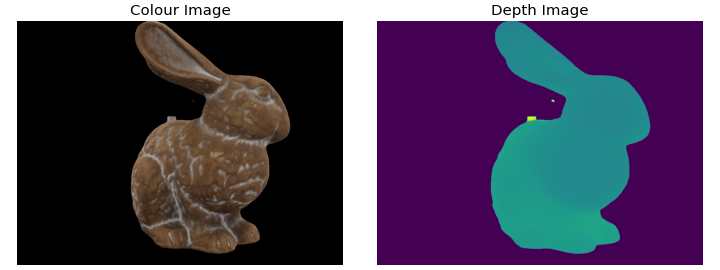

In [49]:
# Load Image from the ./testImages directory
# image_col = load_image("1.jpg")
# image_col = load_image("SB_Quad_5.jpg", "Clouds/StanfordBunny_vp3/photos/")
image_col = load_image("random_0.jpg")
# Compute Depth Map
image_dep = compute_depth(image_col, dev="cpu")

cam_pose = np.array([0,1.6,-2]) # 4
# image_dep = compute_depth_midas(image_col, cam_pose)

# Mask out both Color and Depth images
mask = create_mask(image_col)
image_col_m = mask_out(mask, image_col)
image_dep_m = mask_out(mask, image_dep)

fig, axs = plt.subplots( 1, 2, figsize=(8,3), layout="constrained" )
for title, ax, img in zip([ "Colour Image", "Depth Image" ], axs, [ image_col_m, image_dep_m ]):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
    
    
img_width = image_col.shape[1]
img_height = image_col.shape[0]

# Calculate Occupancy
area = image_dep_m[image_dep_m > 0].size
occupancy = area/image_dep_m.size
occ_R = int(np.sqrt(area / np.pi))

# Calculate Camera Intrinsics
focal_l = 6.0
fx, fy = (focal_l *  img_width/6.287, focal_l *  img_width/6.287)
cx, cy = ( img_width/2, img_height/2 )
intrinsics = o3d.camera.PinholeCameraIntrinsic(img_width, img_height, fx, fy, cx, cy)

<IPython.core.display.Javascript object>


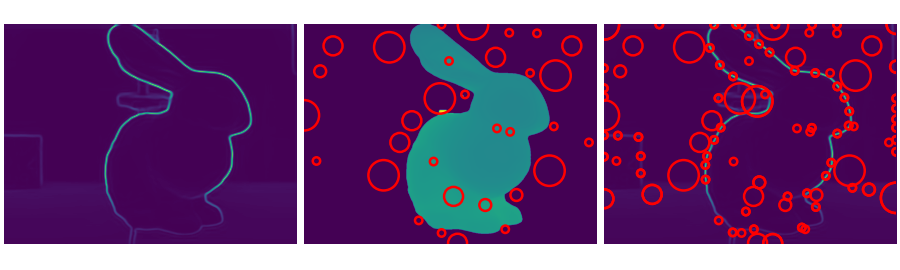

61

In [50]:
def add_patches_to_plot(ax, blob_list):
    for blob in blob_list:
        y, x, r = blob
        c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
        ax.add_patch(c)

# Initialise Sigma Values
min_sigma = int(occ_R*.05)
max_sigma = int(occ_R*.25)

# Compute the Edge map
edge_map = adjust_log(sobel(image_dep, mask=None,  axis=[0,1]))

# Compute blobs from the Depth Map
depth_map_blobs = blob_dog(image_dep, min_sigma=min_sigma, max_sigma=max_sigma,overlap=0.1, threshold=.001)

# Compute blobs from the Edge Map
edge_map_blobs = blob_dog(edge_map, min_sigma=min_sigma, max_sigma=max_sigma, overlap=0.1, threshold=.001)


fig, axs = plt.subplots(1, 3, figsize=(10,3), layout="constrained")

for _ax, _img, _blobs in zip(axs, [edge_map, image_dep_m, edge_map], [[], depth_map_blobs, edge_map_blobs ]):
    add_patches_to_plot(_ax, _blobs)
    _ax.imshow(_img)
    _ax.axis("off")
all_blobs= []
all_blobs = np.concatenate( (depth_map_blobs.copy(), edge_map_blobs.copy()) )
add_patches_to_plot( plt.gca(), all_blobs )
len(edge_map_blobs)

<IPython.core.display.Javascript object>


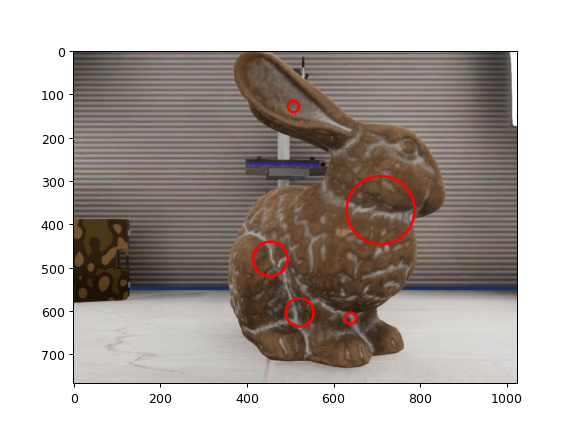

61

In [51]:
selected_bandwidth = (max_sigma+min_sigma) * 1

fitlered_blobs = np.array(filter_blobs(all_blobs, mask))

# Applying Mean Shift Clustering
meanshift = MeanShift(bandwidth=selected_bandwidth)
meanshift.fit(fitlered_blobs[:,:2])
labels = meanshift.labels_
cluster_centers = meanshift.cluster_centers_
n_clusters = len(cluster_centers)

blobs_dict = dict()
for label, blob in zip(labels, fitlered_blobs):
    if label in blobs_dict:
        blobs_dict[label].append(blob)
    else:
        blobs_dict[label] = [blob]

blobs_radii = {}
# Loop over Clusters
for key, blobs in blobs_dict.items():
    _blobs = np.asarray(blobs)    
    if( len(blobs) == 1 ):
        radius = blob[2]
    else:
        x_len = max(_blobs[:,0]) - min(_blobs[:,0])
        y_len = max(_blobs[:,1]) - min(_blobs[:,1])
        radius =  np.sqrt( y_len**2 + x_len**2)/2 + np.mean(_blobs[:,2:])
    blobs_radii[key] = radius 
    
# Form a Blob Structure (x,y radius)
blobs = np.column_stack([cluster_centers, np.array( list(blobs_radii.values()), dtype=float )])
plt.figure()
plt.imshow(image_col)
add_patches_to_plot( plt.gca(), blobs )
len(edge_map_blobs)

## Calculation of Poses

Now we have a list of RoIs. We can now loop over them while calculating their poses.

In [98]:
def isolate_image(image, roi):
    # Extracting the center (y, x) and radius
    y, x, radius = roi
    
    # Calculating the square bounds
    top_y = max(int(y - radius), 0)
    left_x = max(int(x - radius), 0)
    bottom_y = min(int(y + radius), image.shape[0])
    right_x = min(int(x + radius), image.shape[1])

    # Create 
    masked = np.zeros_like(image)    
    cropped_image = image[top_y:bottom_y, left_x:right_x]
    masked[top_y:bottom_y, left_x:right_x] = cropped_image

    return masked

def create_point_cloud(extractions):
    img_rgb, img_dep = extractions
    
    # Scaling factor for the depth image
    _scale = 1000
    
    color_raw_m = o3d.geometry.Image(img_rgb)
    depth_raw_m =  o3d.geometry.Image(img_dep*_scale) 

    # Create RGBD 
    rgbd_image_m = o3d.geometry.RGBDImage.create_from_color_and_depth(
        color_raw_m, 
        depth_raw_m
    )

    # Create Point Cloud
    pcd = o3d.geometry.PointCloud.create_from_rgbd_image( rgbd_image_m, intrinsics )
    
#     pcd.transform([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])
    pcd_points = np.asarray(pcd.points)
    pcd_points[:,1] *= -1
    inv_pc = o3d.geometry.PointCloud()
    inv_pc.points = o3d.utility.Vector3dVector(pcd_points)
    
    # Estimate Normals
    inv_pc.estimate_normals( search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=.1, max_nn=30))
    inv_pc.orient_normals_towards_camera_location()

    # Create Numpy Arrays for the points and corresponding normals.
    pcd_p = np.asarray(inv_pc.points)
    pcd_n = np.asarray(inv_pc.normals)
    
    return inv_pc, pcd_p, pcd_n


def retrieve_normal(points, normals):
    # Calculate the centroid
    centroid = np.mean(points, axis=0)
    normal = np.mean(normals, axis=0)

    # Find the index of the point closest to the centroid
    distances = np.linalg.norm(points - centroid, axis=1)
    closest_point_index = np.argmin(distances)

    # Get the normal at the closest point
    closest_normal = normals[closest_point_index]
    
    return centroid, (closest_normal+normal)/2

def add_normal_to_plotter(plotter, point, normal, col="red"):
    arrow = pv.Arrow(start=point, direction=normal, scale=.2)  # Adjust scale as needed
    plotter.add_mesh(arrow, color=col)

def normalise_vector(vec):
    norm = np.linalg.norm(vec)
    if norm == 0: 
        normalized_v = vec
    else:
        normalized_v = vec / norm
    
    return normalized_v

    # Convert the input lists to numpy arrays
    v1 = np.array(vector1)
    v2 = np.array(vector2)

    # Calculate the dot product of the two vectors
    dot_product = np.dot(v1, v2)

    # Calculate the magnitudes of the vectors
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    # Calculate the cosine of the angle between the vectors
    cosine_theta = dot_product / (magnitude_v1 * magnitude_v2)

    # Use arccosine to get the angle in radians
    angle_radians = np.arccos(cosine_theta)

    # Convert the angle to degrees
    angle_degrees = np.degrees(angle_radians)

    return angle_degrees

def angle_difference(v1, v2):
    '''
        Returns: angle_degrees and angle_radians
    '''
    dot_product = np.dot(v1, v2)

    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    # Calculate the cosine of the angle between the vectors
    cosine_theta = dot_product / (magnitude_v1 * magnitude_v2)

    # Use arccosine to get the angle in radians
    angle_radians = np.arccos(cosine_theta)

    # Convert the angle to degrees
    angle_degrees = np.degrees(angle_radians)

    return angle_degrees, angle_radians

`ed_mean` Average Distance from the Centroid to all points.

The minimum working distance is a function of the Euclidean Distance

A floor level has to be established to avoid collision. This is represented by the variable `y_min` \

**Objective** Increase Internal Angle to achieve collinearity of the secondary pose with the RoI and Viewpoint Centroid. The `delta_angle` therefore needs to be decreased; it's value shows how much room is available. Howver, the size of the blob has influence, whereby for small blobs, the angle has to be relatively small compaed to bigger blobs.

$$ \text{Angle} \phi = F(b, \delta, )$$

A definite overlap value should work considering that rotation is about the `RoI`

In [99]:
# Hold all the Poses
local_poses = list()

def generate_poses(plotter, blobs, image_col_m, image_dep_m, ):
    for blob in blobs:
        # Get Blob Centroid and Normal
        roi_col = isolate_image( image_col_m, blob )
        roi_dep = isolate_image( image_dep_m, blob )
        pcd, points, normals = create_point_cloud( [ roi_col, roi_dep ] )
        centroid, normal = retrieve_normal(points, normals)
        
        # Create and add a sphere to represent a single point
        sphere = pv.Sphere(radius=.02, center=centroid)
        plotter.add_mesh(sphere, color='blue')
        
        # Calculate Primary Pose Position and Orientation
        blob_size_s = int(blob[2])/Rad
        wd = np.clip( blob_size_s * WD, ed_mean + (ed_stdv*2), WD )
        priPose_loc = (normal * wd) + centroid
        
        # Avoid Floor Collision
        if priPose_loc[1] < y_min:
            print(f"Point: {priPose_loc} is below the floor at {y_min}" )
            priPose_loc[1] = y_min
            print(f"New Position: {priPose_loc}")
        priPose_rot = normalise_vector(centroid - priPose_loc)
        local_poses.append({ "pos" : priPose_loc, "rot" : priPose_rot })
        add_normal_to_plotter(plotter,priPose_loc, priPose_rot, "blue")

        # Get Secondary Pose
        v1 = priPose_loc - centroid
        v2 = viewpoint_centroid - centroid
        _, internal_angle = angle_difference(v1, v2)
        delta_angle = np.pi - internal_angle
        
        # Calculate Secondary Pose
        normal = np.cross(v1, v2)
        rot_axis = normal / np.linalg.norm(normal)
        theta = -np.pi/12
        
        quat = R.from_rotvec(theta * rot_axis) # Create a quaternion for the rotation
        secPose_loc = quat.apply(v1) + centroid
        
        if secPose_loc[1] < y_min:
            print(f"Point: {secPose_loc} is below the floor at {y_min}" )
            secPose_loc[1] = y_min
            
            v3 = secPose_loc - centroid
            v4 = priPose_loc - centroid
            _deg, delta_angle2 = angle_difference(v3, v4)
            
            print(f"New Angle Delta: {_deg}")
            
            rot_axis2 = np.cross(v3, v4)
            rot_axis2 = rot_axis2/ np.linalg.norm(rot_axis2)
            quat2 = R.from_rotvec( (theta - delta_angle2)/2  * rot_axis2) # Create a quaternion for the rotation
            secPose_loc = quat2.apply(v3) + centroid
            secPose_loc[1] = y_min
            
        secPose_rot = normalise_vector( centroid - secPose_loc )
        local_poses.append({ "pos" : secPose_loc, "rot" : secPose_rot })
        add_normal_to_plotter(plotter,secPose_loc, secPose_rot, "yellow")
        
        

# Prepare the Point Cloud
viewpoint_pcd,viewpoint_points, viewpoint_normals = create_point_cloud( [ image_col_m, image_dep_m ] )
viewpoint_centroid = np.mean(viewpoint_points, axis=0)

# Get Baselines for Blob Radius and Primar Pose Distance
eds = np.sqrt(np.sum((viewpoint_points - viewpoint_centroid)**2, axis=1))
ed_mean = np.mean(eds) 
ed_stdv = np.std(eds)
min_wd = ed_mean + (2 * ed_stdv)

WD = np.min(image_dep_m[image_dep_m > 0])
Rad = int(np.max(blobs[:,2]))
camera_offset = 0.1
y_min = np.ceil( np.min(viewpoint_points[:,1]) * 100)/100 + camera_offset


plotter = pv.Plotter()
vp_cloud = pv.PolyData(viewpoint_points)
plotter.add_points(vp_cloud, point_size=1, render_points_as_spheres=True)

generate_poses(plotter, blobs, image_col_m, image_dep_m)

# Create and add a sphere to represent a single point
centroid_sphere = pv.Sphere(radius=.05, center=viewpoint_centroid)

plotter.add_mesh(centroid_sphere, color='green')
plotter.view_xz()
plotter.show_grid()
plotter.show_axes()
plotter.show()


Point: [   -0.18227    -0.60785      1.1739] is below the floor at -0.51
New Position: [   -0.18227       -0.51      1.1739]
Point: [   -0.22119    -0.64329      1.2412] is below the floor at -0.51
New Angle Delta: 6.373090344611156
Point: [    0.27055    -0.57343     0.47265] is below the floor at -0.51
New Position: [    0.27055       -0.51     0.47265]
Point: [     0.3894    -0.81946      1.3205] is below the floor at -0.51
New Position: [     0.3894       -0.51      1.3205]
Point: [     0.4235    -0.61763       1.373] is below the floor at -0.51
New Angle Delta: 6.561506247788679


Widget(value="<iframe src='http://localhost:39163/index.html?ui=P_0x71ab7154cf40_16&reconnect=auto' style='wid…

INFO:wslink.backends.aiohttp:client 73afb4d8545d4437863fe5c59b1aa0e8 disconnected
INFO:wslink.backends.aiohttp:No more connections, scheduling shutdown
INFO:aiohttp.access:127.0.0.1 [08/Mar/2024:13:01:06 +0300] "GET /ws HTTP/1.1" 101 0 "-" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36"
INFO:aiohttp.access:127.0.0.1 [08/Mar/2024:13:04:21 +0300] "GET /index.html?ui=P_0x71ab7154cf40_16&reconnect=auto HTTP/1.1" 200 235 "http://127.0.0.1:8888/" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36"
INFO:aiohttp.access:127.0.0.1 [08/Mar/2024:13:04:21 +0300] "POST /paraview/ HTTP/1.1" 405 207 "http://localhost:39163/index.html?ui=P_0x71ab7154cf40_16&reconnect=auto" "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36"
INFO:wslink.backends.aiohttp:client ec76f558f4474173ab40d2945a159d3d connected


In [117]:
for i in range(len(local_poses)):
    print(local_poses[i]["pos"])

[   -0.18227       -0.51      1.1739]
[   -0.30502       -0.51      1.2972]
[    0.27055       -0.51     0.47265]
[    0.51526    -0.35132     0.42518]
[     0.3894       -0.51      1.3205]
[    0.49257       -0.51      1.4188]
[   -0.40961    -0.22176       1.088]
[   -0.52732    -0.28667      1.1862]
[   0.051526     0.29025     0.92165]
[  0.0097467     0.44234     0.91108]


In [118]:
local_poses[2]["rot"]
forward = np.array([0,0,1])
import numpy as np

def angle_difference_on_planes(vector):
    # Ensure the input vector is a NumPy array
    vector = np.array(vector)

    # Normalize the input vector
    vector /= np.linalg.norm(vector)

    # Calculate the angle difference on the YZ plane
    angle_xy = np.arctan2(vector[0], vector[1])
    
    # Calculate the angle difference on the XZ plane
    angle_xz = np.arctan2(vector[0], vector[2])

    # Calculate the angle difference on the YZ plane
    angle_yz = np.arctan2(vector[1], vector[2])

    # Convert angles from radians to degrees
    angle_xy_deg = np.degrees(angle_xy)
    angle_xz_deg = np.degrees(angle_xz)
    angle_yz_deg = np.degrees(angle_yz)
    

    return angle_xy_deg, angle_xz_deg, angle_yz_deg

# Example usage
angle_xy, angle_xz, angle_yz = angle_difference_on_planes(local_poses[9]["rot"])

print("Angle difference on XZ plane:", angle_xz, "degrees")
print("Angle difference on YZ plane:", angle_yz, "degrees")


Angle difference on XZ plane: -1.585531883329804 degrees
Angle difference on YZ plane: -4.24242826618691 degrees


In [127]:
np.degrees(np.arctan2(local_poses[2]["rot"][2], local_poses[9]["rot"][1]))

94.80171481620211